## Actividad 3_18: Clasificación de Pistachos


<div style="border-style:groove;border-width:thin;padding:10px">
Antes de empezar, vamos a importar los datos. En la misma carpeta de este notebook deberías tener una carpeta llamada training. Dentro de ésta estarán las imágenes separadas en dos carpetas, cada una con un tipo.
</div>

In [172]:
from os import listdir
from numpy import asarray
from numpy import save
import tensorflow as tf
#Deshabilitar la GPU:
#tf.config.set_visible_devices([], 'GPU')
from tensorflow import keras
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

folders = listdir('./training')
#Clase Kirmizi será la clase 0.0
#Clase Siirt será la clase 1.0


photos =  []
labels = []

In [173]:
#2. IMPORTAMOS LOS DATOS:
for idx,folder in enumerate(folders):
    for file in listdir('./training/'+folder):
        #Cargamos la imagen.
        #load_img sirve para cargar las imágenes en memoria. Tiene distintos parámetros para modificar como se cargan las imágenes.
        photo = load_img('./training/'+folder+'/' + file, color_mode='grayscale', target_size=(250, 250)) 
        #Convertimos la imagen a un array.
        photo = img_to_array(photo)
        #Los guardamos en las listas.
        photos.append(photo)
        labels.append(float(idx))
        del photo
    print(idx)

0
1


In [174]:
print("Número de fotos cargadas:", len(photos))
print("Número de etiquetas cargadas:", len(labels))
print(labels)
photos = asarray(photos).astype('float32') / 255.0
photos = asarray(photos).reshape(len(photos), -1)
labels = asarray(labels) 

Número de fotos cargadas: 1813
Número de etiquetas cargadas: 1813
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(photos, labels, test_size=0.2, random_state=42)

In [176]:
X_train.shape[1:]

(62500,)

In [177]:
model = keras.models.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]), 
    keras.layers.Dense(3000, activation='relu'),
    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])



In [178]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 3000)           │   187,503,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,505,001 (726.72 MB)

 Trainable params: 190,505,001 (726.72 MB)

 Non-trainable params: 0 (0.00 B)

In [179]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.01),metrics=['accuracy'])

In [180]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_split=0.1)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.6920 - loss: 0.6694 - val_accuracy: 0.7862 - val_loss: 0.4847
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.7716 - loss: 0.4722 - val_accuracy: 0.8207 - val_loss: 0.4048
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.7985 - loss: 0.4253 - val_accuracy: 0.8345 - val_loss: 0.3767
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.8176 - loss: 0.4013 - val_accuracy: 0.8276 - val_loss: 0.3801
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.8084 - loss: 0.3993 - val_accuracy: 0.7517 - val_loss: 0.4984
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.8199 - loss: 0.3848 - val_accuracy: 0.8069 - val_loss: 0.4363
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.8360 - loss: 0.3759 - val_accuracy: 0.8138 - val_loss: 0.4076
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.8276 - loss: 0.3861 - val_accuracy: 0.

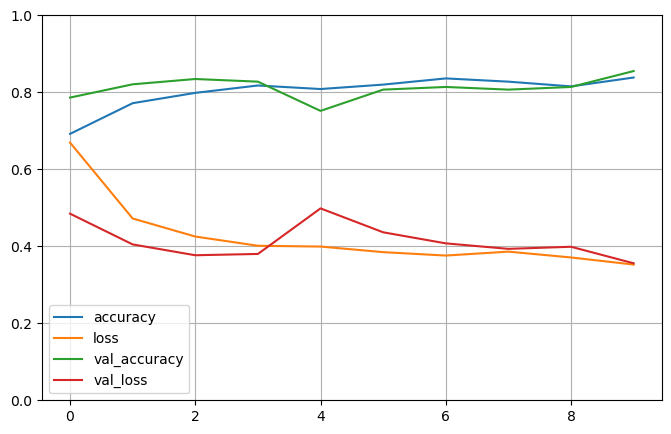

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [182]:
model.evaluate(X_test, y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8347 - loss: 0.3469


[0.34688079357147217, 0.8347107172012329]

In [183]:
model.save('Modelo_Manu.keras')